# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [41]:
!pip install cvxopt

### Package Imports

In [42]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
!pip install scipy
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
!pip install scikit-learn
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [43]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [44]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [45]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


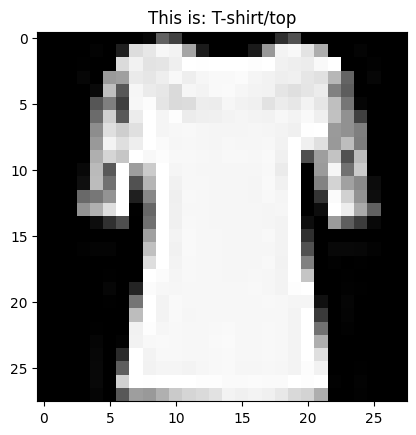

In [46]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [47]:
def rbf_kernel(X1, X2, gamma=0.01):
    X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
    X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
    sq_dist = X1_sq + X2_sq - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * sq_dist)

# Calculate gamma based on features (784 for Fashion-MNIST)
gamma_val = 1 / X_train.shape[1] 
best_C = 10.0
kernel_func = lambda x1, x2: rbf_kernel(x1, x2, gamma=gamma_val)

In [48]:
class SVM:
    def __init__(self, kernel_func, C=1.0):
        self.kernel_func = kernel_func
        self.C = float(C)
        self.alphas = None
        self.sv_X = None
        self.sv_y = None
        self.b = 0.0

    def fit(self, X, y):
        n_samples = X.shape[0]
        K = self.kernel_func(X, X)

        # Task 1: Formulate the Quadratic Programming problem
        # Minimize 1/2 a.T * P * a + q.T * a
        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))
        
        # Inequality constraints: 0 <= alpha <= C
        # G*a <= h -> [I; -I]*a <= [C; 0]
        G = matrix(np.vstack((np.eye(n_samples), -np.eye(n_samples))))
        h = matrix(np.hstack((np.ones(n_samples) * self.C, np.zeros(n_samples))))
        
        # Equality constraint: y.T * a = 0
        A = matrix(y.reshape(1, -1).astype(float))
        b_zero = matrix(0.0)

        # Solve
        solution = solvers.qp(P, q, G, h, A, b_zero)
        alphas = np.ravel(solution['x'])

        # Identify Support Vectors (alphas > 0)
        is_sv = alphas > 1e-5
        self.alphas = alphas[is_sv]
        self.sv_X = X[is_sv]
        self.sv_y = y[is_sv]

        # Task 2: Calculate bias 'b' using Bishop (7.37)
        # Average over support vectors where 0 < alpha < C for stability
        margin_sv = (alphas > 1e-5) & (alphas < self.C - 1e-5)
        if np.any(margin_sv):
            idx = np.where(margin_sv)[0][0]
            # b = t_n - sum(alpha_m * t_m * K(x_m, x_n))
            term = np.sum(self.alphas * self.sv_y * self.kernel_func(self.sv_X, X[idx:idx+1]).flatten())
            self.b = y[idx] - term
        else:
            self.b = np.mean(self.sv_y - np.dot(K[is_sv][:, is_sv], self.alphas * self.sv_y))

    def predict_score(self, X):
        """Returns the raw decision function value."""
        k_matrix = self.kernel_func(X, self.sv_X)
        return np.dot(k_matrix, self.alphas * self.sv_y) + self.b

    def predict(self, X):
        return np.sign(self.predict_score(X))

## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [49]:
class OneVsRestSVM:
    def __init__(self, kernel_func, C=1.0):
        self.kernel_func = kernel_func
        self.C = C
        self.models = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for cls in self.classes:
            y_binary = np.where(y == cls, 1, -1)
            model = SVM(self.kernel_func, self.C)
            model.fit(X, y_binary)
            self.models[cls] = model

    def predict(self, X):
        scores = np.column_stack([self.models[cls].predict_score(X) for cls in self.classes])
        return self.classes[np.argmax(scores, axis=1)]

class OneVsOneSVM:
    def __init__(self, kernel_func, C=1.0):
        self.kernel_func = kernel_func
        self.C = C
        self.models = []

    def fit(self, X, y):
        self.classes = np.unique(y)
        for cls1, cls2 in combinations(self.classes, 2):
            mask = (y == cls1) | (y == cls2)
            X_pair, y_pair = X[mask], np.where(y[mask] == cls1, 1, -1)
            model = SVM(self.kernel_func, self.C)
            model.fit(X_pair, y_pair)
            self.models.append((cls1, cls2, model))

    def predict(self, X):
        votes = np.zeros((X.shape[0], len(self.classes)))
        class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
        for cls1, cls2, model in self.models:
            preds = model.predict(X)
            for i, p in enumerate(preds):
                winner = cls1 if p == 1 else cls2
                votes[i, class_to_idx[winner]] += 1
        return self.classes[np.argmax(votes, axis=1)]

## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

In [50]:
# Hyperparameters
gamma_val = 1 / X_train.shape[1]
best_C = 10.0  # High C as per hint

# Initialize and Train
ovr_clf = OneVsRestSVM(lambda x1, x2: rbf_kernel(x1, x2, gamma=gamma_val), C=best_C)
ovo_clf = OneVsOneSVM(lambda x1, x2: rbf_kernel(x1, x2, gamma=gamma_val), C=best_C)

print("Training One-vs-Rest...")
ovr_clf.fit(X_train, y_train)

print("Training One-vs-One...")
ovo_clf.fit(X_train, y_train)

# Accuracy Check
y_pred_ovr = ovr_clf.predict(X_test)
y_pred_ovo = ovo_clf.predict(X_test)

print(f"OvR Accuracy: {np.mean(y_pred_ovr == y_test) * 100:.2f}%")
print(f"OvO Accuracy: {np.mean(y_pred_ovo == y_test) * 100:.2f}%")

Training One-vs-Rest...
Training One-vs-One...
OvR Accuracy: 84.00%
OvO Accuracy: 83.00%


## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

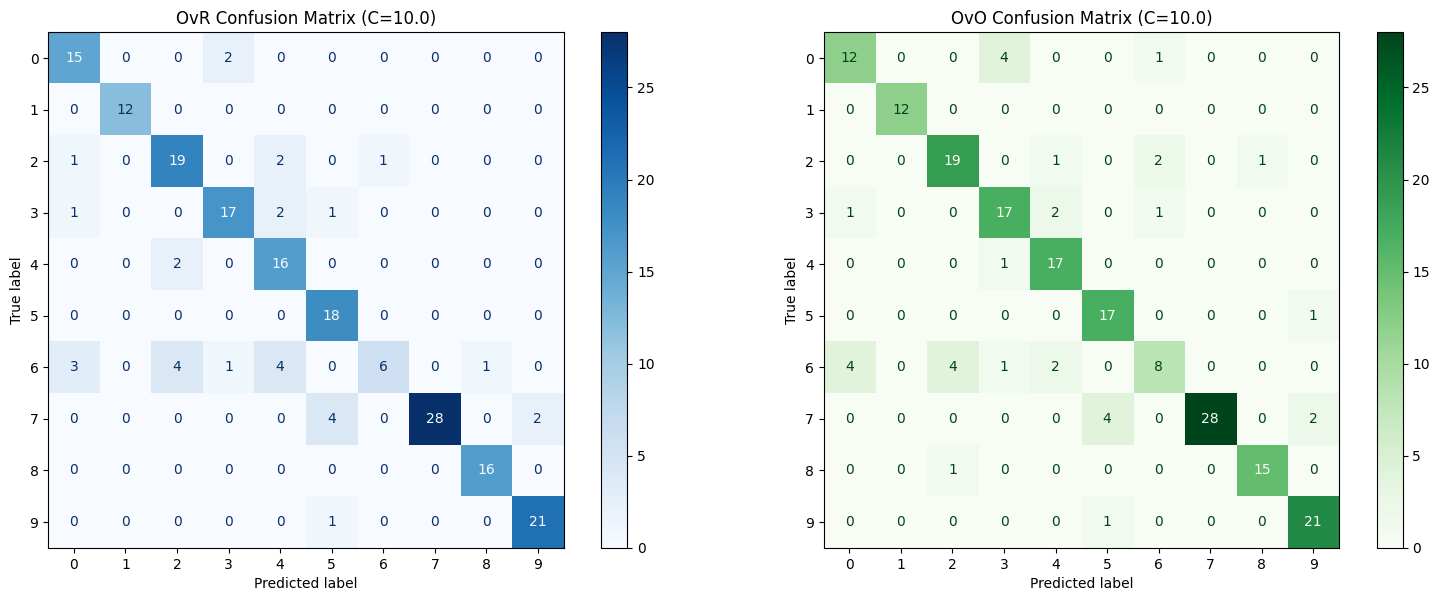

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Labels for Fashion-MNIST
labels = [str(i) for i in range(10)]

# OvR Matrix
cm_ovr = confusion_matrix(y_test, y_pred_ovr)
ConfusionMatrixDisplay(cm_ovr, display_labels=labels).plot(cmap='Blues', ax=ax[0])
ax[0].set_title(f"OvR Confusion Matrix (C={best_C})")

# OvO Matrix
cm_ovo = confusion_matrix(y_test, y_pred_ovo)
ConfusionMatrixDisplay(cm_ovo, display_labels=labels).plot(cmap='Greens', ax=ax[1])
ax[1].set_title(f"OvO Confusion Matrix (C={best_C})")

plt.tight_layout()
plt.show()

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.